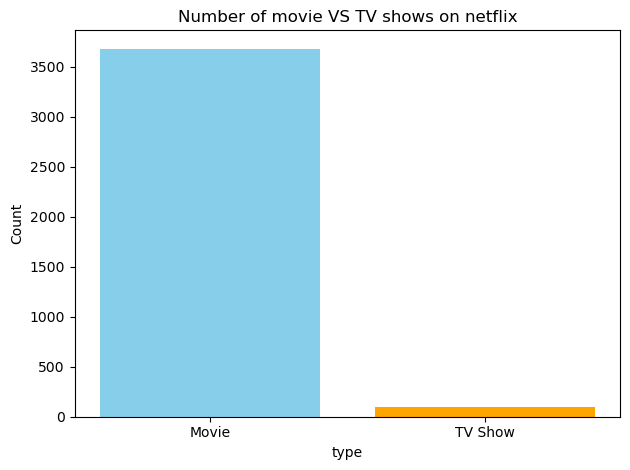

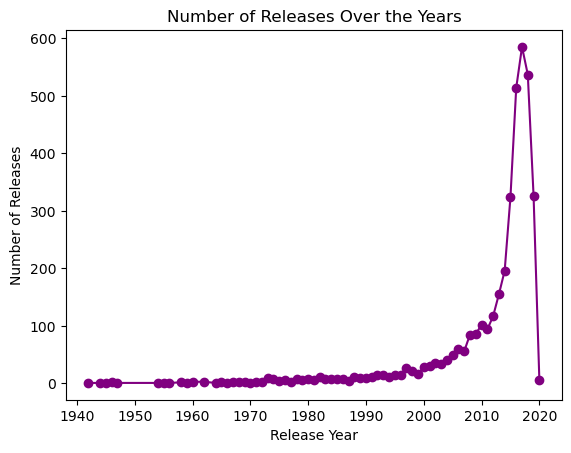

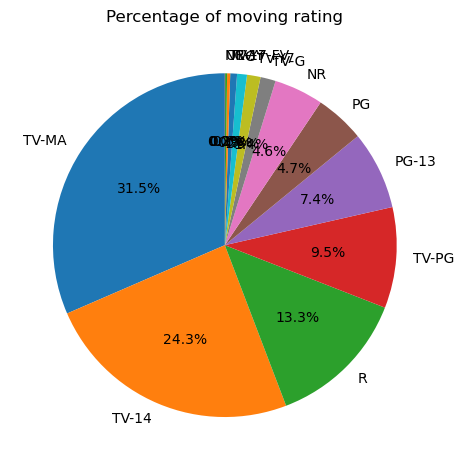

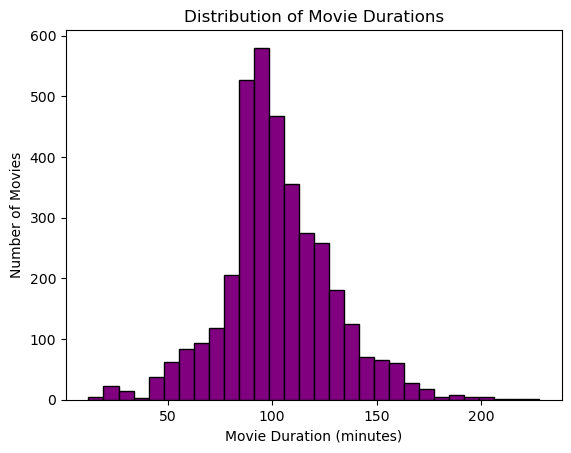

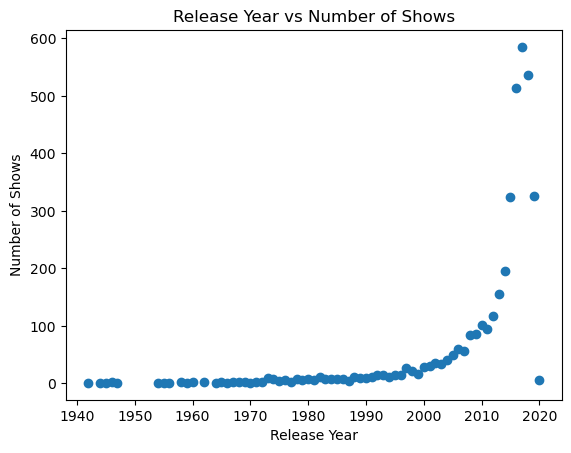

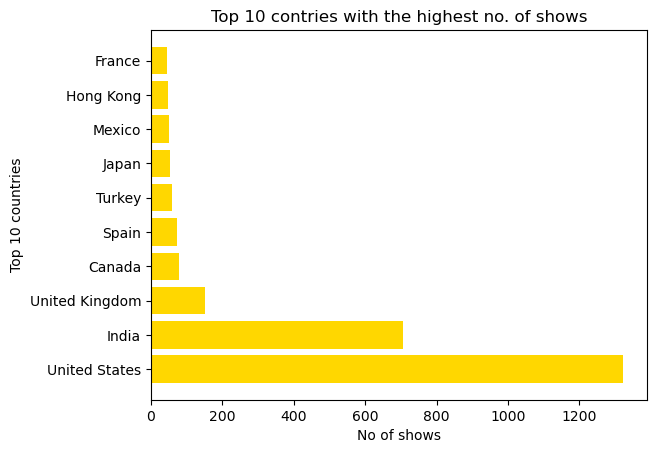

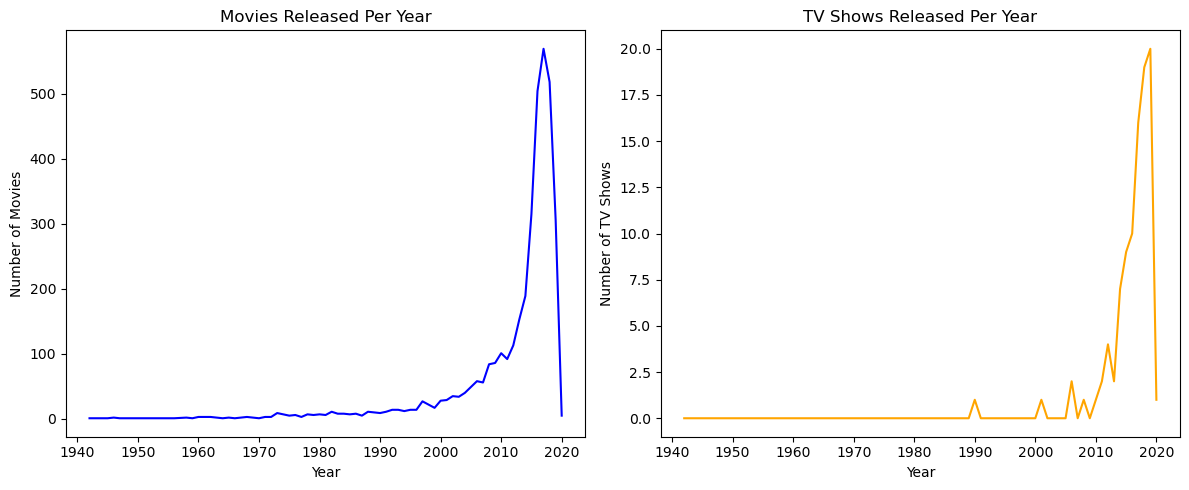

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

#load the data
df = pd.read_csv("netflix_titles.csv")

#clean data
df = df.dropna(subset=["director","cast","country","date_added","rating"])

#bar chart for count movie vs tv show in netflix
type_count = df["type"].value_counts()
plt.Figure(figsize=(6,4))
plt.bar(type_count.index , type_count.values , color=["skyblue","orange"])
plt.title("Number of movie VS TV shows on netflix")
plt.xlabel("type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# line plot for no of releases changed over the year

release_count = df['release_year'].value_counts().sort_index()

plt.plot(release_count.index, release_count.values , color="purple" , marker="o")

plt.xlabel('Release Year')
plt.ylabel('Number of Releases')
plt.title('Number of Releases Over the Years')

plt.show()

# pie chart for % of each content rating 
rating_count = df["rating"].value_counts()
plt.Figure(figsize=(6,4))
plt.pie(rating_count, labels=rating_count.index , autopct="%1.1f%%", startangle=90)
plt.title("Percentage of moving rating")
plt.tight_layout()
plt.show()

# histogram of movie duration distribution 
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)
import matplotlib.pyplot as plt

plt.hist(movies['duration'], bins=30 , color="purple" , edgecolor="black")
plt.xlabel('Movie Duration (minutes)')
plt.ylabel('Number of Movies')
plt.title('Distribution of Movie Durations')
plt.show()

# relationship between release year and no of shows

year_count = df['release_year'].value_counts().sort_index()

plt.scatter(year_count.index, year_count.values)

plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.title('Release Year vs Number of Shows')

plt.show()

# top 10 contries with the highest no. of shows
country = df["country"].value_counts().head(10)

plt.barh(country.index , country.values , color ="gold")
plt.xlabel('No of shows')
plt.ylabel('Top 10 countries')
plt.title('Top 10 contries with the highest no. of shows')
plt.show()

#subplot 
content_by_year = df.groupby(
    ['release_year', 'type']
).size().unstack().fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Movies
ax[0].plot(
    content_by_year.index,
    content_by_year['Movie'],
    color='blue'
)

ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')


# Second subplot: TV Shows
ax[1].plot(
    content_by_year.index,
    content_by_year['TV Show'],
    color='orange'
)

ax[1].set_title('TV Shows Released Per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')

plt.tight_layout()
plt.show()